# Домашнее задание 2. Работа с изображениями

В этом задании предлагается решить простейшую задачу рапознавания лиц. Вам нужно будет научить модель для пары картинок определять, разные ли люди на них изображены.

Работать будем с датасетом фотографий известных людей. Скачать его можно [тут](https://disk.360.yandex.ru/d/oAmJgPESjP33hg). В нём представлены 150 человек, для каждого по 6-9 фотографий. Всего около 1000 изображений.

__Задание__. Вам потребуется выполнить два задания:

1) Реализовать модель бинарной классификации и добиться приемлемого качества.

2) Реализовать триплетную функцию потерь и улучшить качество предсказаний с ее помощью.

Напишите краткий отчёт о проделанных экспериментах. Что сработало и что не сработало? Почему вы решили, сделать так, а не иначе? Обязательно указывайте ссылки на чужой код, если вы его используете. Обязательно ссылайтесь на статьи / блогпосты / вопросы на stackoverflow / видосы от ютуберов-машинлернеров / курсы / подсказки от Дяди Васи и прочие дополнительные материалы, если вы их используете.

__Во всех заданиях будем придерживаться следующих правил__:
1. Использовать внешние данные для обучения строго запрещено. Также запрещено обучаться на валидационной выборке.
2. Все задания должны быть выполнены без использования предобученных моделей и готовых реализаций. Тем не менее:
    - В заданиях, где требуется достичь некоторого качества модели, разрешается использовать предобученные модели. Но __оценка за задние будет снижена__ (для каждого задания будет отдельно указано, на сколько).
    - В некоторых заданиях может сильно помочь библотека [pytorch-metric-learning](https://kevinmusgrave.github.io/pytorch-metric-learning/). Вы можете использовать готовые реализации из неё, но __максимальный балл за задание также будет снижен__.

__Советы и указания__:
 - Наверняка вам потребуется много гуглить о том, как заставить это всё работать. Это нормально, все гуглят. Но не забывайте, что нужно быть готовым за скатанный код отвечать :)
 - Рекомендуем использовать шаблоны ниже. Однако делать это мы не заставляем. Если вам так неудобно, то можете писать код в удобном стиле. Однако учтите, что чрезмерное изменение нижеперечисленных шаблонов увеличит количество вопросов к вашему коду :)
 - Валидируйте. Трекайте ошибки как можно раньше, чтобы не тратить время впустую.
 - Чтобы быстро отладить код, пробуйте обучаться на маленькой части датасета (скажем, 5-10 картинок просто чтобы убедиться что код запускается). Когда вы поняли, что смогли всё отдебажить, переходите обучению по всему датасету
 - На каждый запуск делайте ровно одно изменение в модели/аугментации/оптимайзере, чтобы понять, что и как влияет на результат.
 - Фиксируйте random seed.
 - Правильно нормализуйте данные при создании, пример [тык, но тут и в целом гайд от и до](https://www.pluralsight.com/guides/image-classification-with-pytorch)
 - Начинайте с простых моделей и постепенно переходите к сложным. Обучение лёгких моделей экономит много времени. Можно написать свою модель руками, а можно импортировать не предобученную сетку известной архитектуры из модуля `torchvision.models`. Один из способов как можно сделать: [документация (полезная)](https://pytorch.org/vision/stable/models.html)
 - Используйте все возможные методы оптимизации и эксперемнтируйте с ними.
 - Ставьте расписание на learning rate. Уменьшайте его, когда лосс на валидации перестаёт убывать.
 - Model Checkpointing. Сохраняйте свой прогресс (модели), чтобы когда что-то пойдет не так вы сможете начать с этого места или просто воспроизвести свои результаты модели, которые обучали.
    * Пример как можно с wandb тут: [Сохраняем лучшие модели в wandb](https://docs.wandb.ai/guides/integrations/lightning)
    * По простому можно так: [Сохраняем модели в pytorch дока](https://pytorch.org/tutorials/beginner/saving_loading_models.html)
 - Советуем использовать GPU. Если у вас его нет, используйте google colab. Если вам неудобно его использовать на постоянной основе, напишите и отладьте весь код локально на CPU, а затем запустите уже написанный ноутбук в колабе.

Good luck & have fun! :)

In [ ]:
import os
import tqdm
import numpy
import torch
import pandas
import random
import torchvision
import sklearn.metrics
import torch.utils.data
import matplotlib.pyplot as plt
import torchvision.transforms.v2

In [ ]:
# Можно использовать, но балл за соответствующие задания будет снижен.
import pytorch_metric_learning.distances
import pytorch_metric_learning.samplers
import pytorch_metric_learning.losses

In [ ]:
# Обязательно вызывайте эту функцию перед каждый запуском обучения!
# Если проверяющий не сможет воспроизвести результат, оценка за задание будет снижена.
def set_random_seed(seed: int = 42):
    random.seed(seed)
    numpy.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.backends.cudnn.deterministic = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

### [1.5 балла] Часть 1. Подготовка данных.

##### [0.5 балла] Задание 1.1. Считать датасет.

Сначала нужно считать датасет с фотографиями и посмотреть на его устройство.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms

In [ ]:
# сначала рассчитаем среднее и стандартное отклонения для того, чтобы сделать нормализацию
transform_1 = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

dataset = datasets.ImageFolder("/content/drive/MyDrive/Colab Notebooks/data/training", transform=transform_1)
loader = DataLoader(dataset, batch_size=64, shuffle=False, num_workers=2)

mean = 0.
std = 0.
total = 0

for images, _ in loader:
    batch_samples = images.size(0)
    images = images.view(batch_samples, images.size(1), -1)

    mean += images.mean(2).sum(0)
    std += images.std(2).sum(0)
    total += batch_samples

mean /= total
std /= total

print(f"Среднее: {mean}")
print(f"Стандартное отклонение:  {std}")

Среднее: tensor([0.4299, 0.3747, 0.3325])
Стандартное отклонение:  tensor([0.2673, 0.2403, 0.2306])


In [ ]:
### YOUR CODE HERE ###
transform = transforms.Compose([
    transforms.CenterCrop(150),
    transforms.Resize(128),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4299, 0.3747, 0.3325],std=[0.2673, 0.2403, 0.2306])
])
train_ds = torchvision.datasets.ImageFolder("/content/drive/MyDrive/Colab Notebooks/data/training", transform = transform)
test_ds = torchvision.datasets.ImageFolder("/content/drive/MyDrive/Colab Notebooks/data/testing", transform = transform)

Давайте посмотрим на примеры фотографий. Нарисуйте несколько.

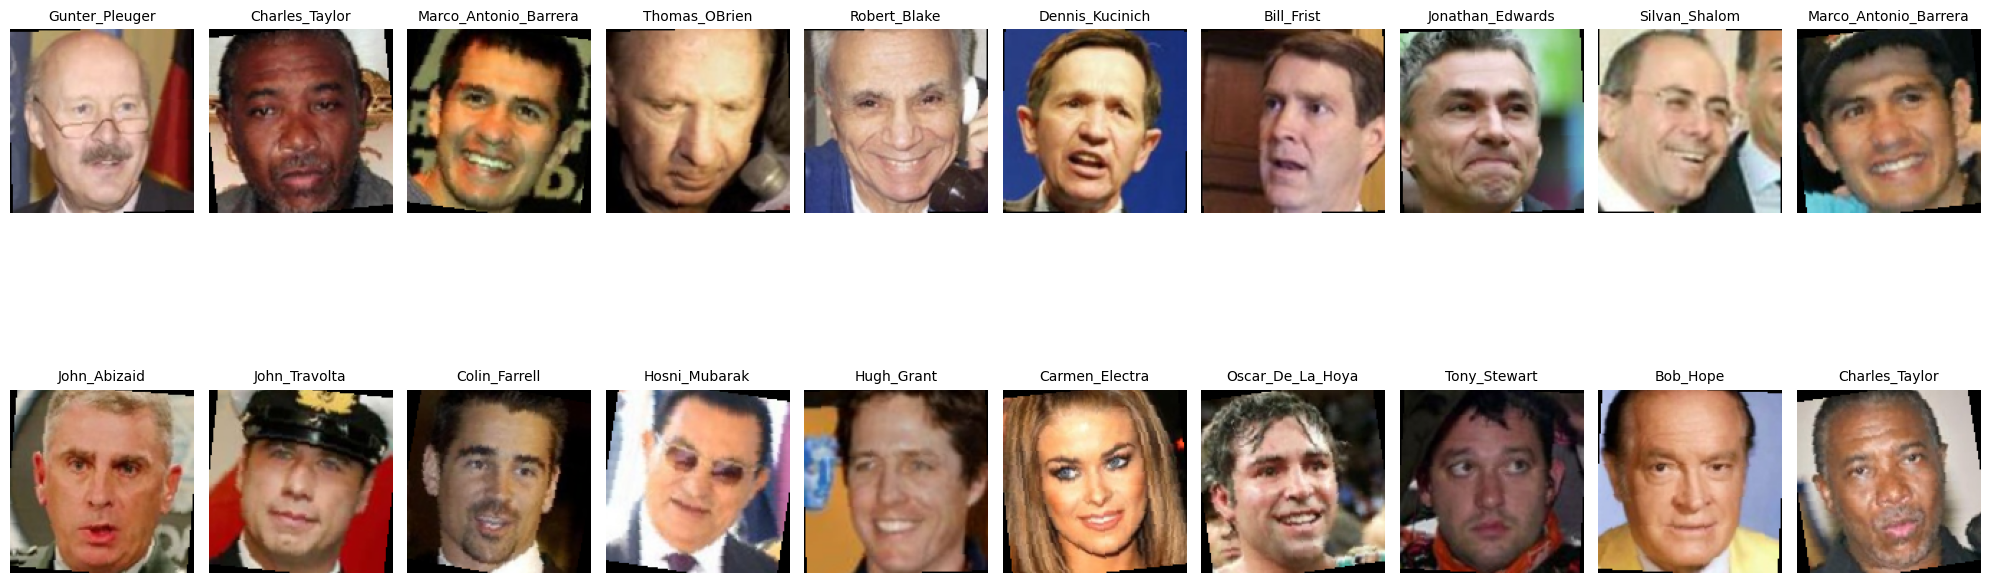

In [ ]:
import matplotlib.pyplot as plt
import torch

set_random_seed(42)
loader = torch.utils.data.DataLoader(train_ds, batch_size=20, shuffle=True)
images, labels = next(iter(loader))

mean = torch.tensor([0.4299, 0.3747, 0.3325]).view(3,1,1)
std = torch.tensor([0.2673, 0.2403, 0.2306]).view(3,1,1)

images = images * std + mean  # денормализация
images = images.permute(0, 2, 3, 1)

class_names = train_ds.classes

fig, axes = plt.subplots(2, 10, figsize=(20,9))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(images[i].numpy())
    ax.set_title(class_names[labels[i]], fontsize=10)
    ax.axis('off')
plt.tight_layout()
plt.show()

Наконец, следует вывести распределение фотографий по людям и убедиться, что для каждого человека действительно предствалено 6-9 фотографий.

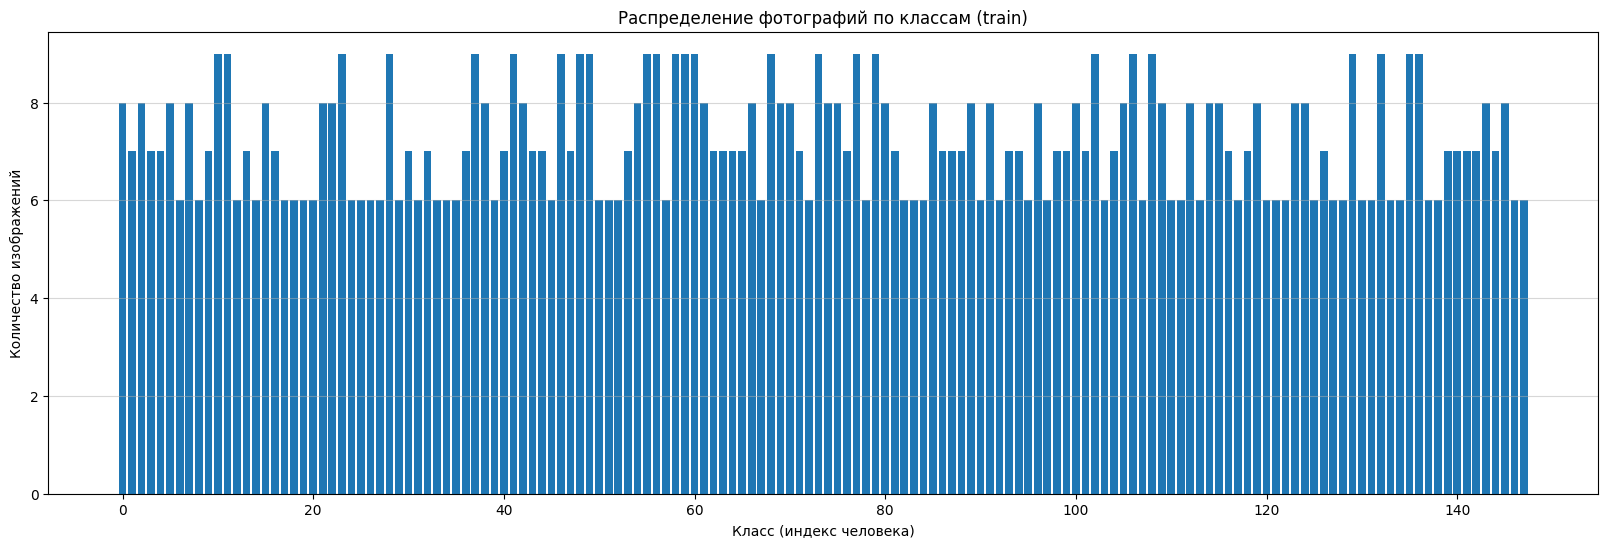

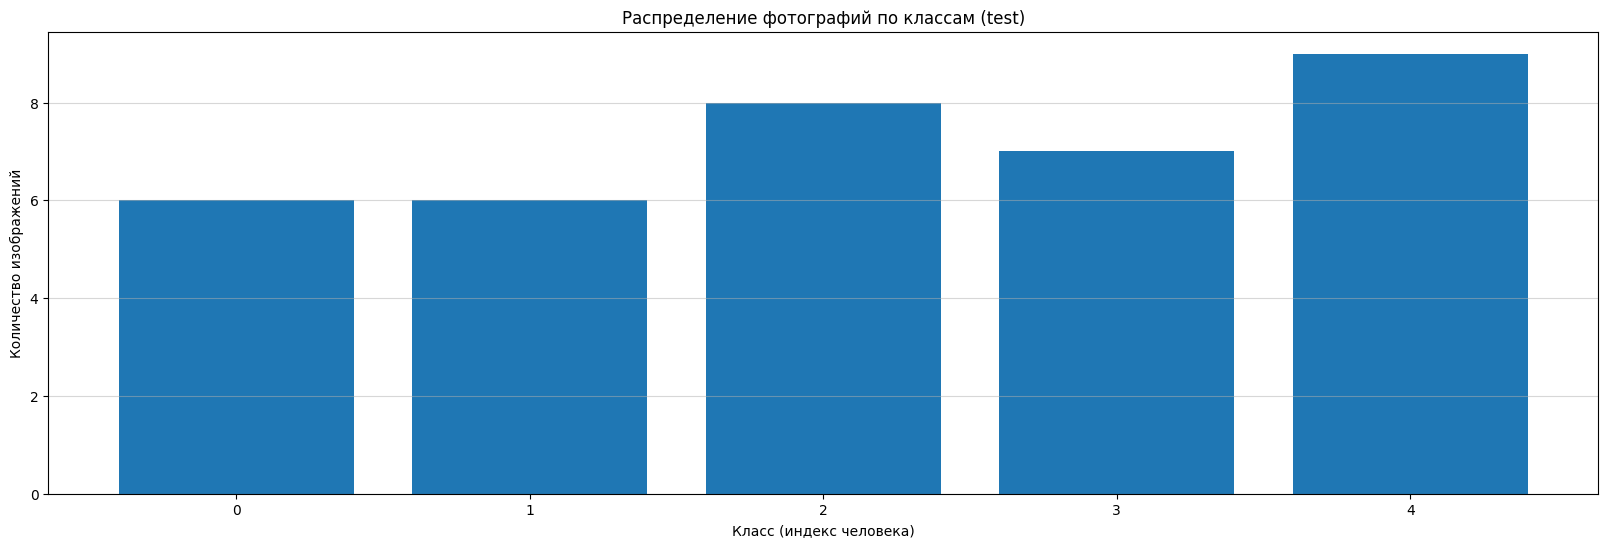

In [ ]:
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np

def show_class_distribtion(targets, title=None):

    class_counts = Counter(np.array(targets)) # вычисляем сколько изображений прихоится на каждый класс
    keys = sorted(class_counts.keys())
    counts = [class_counts[k] for k in keys]

    plt.figure(figsize=(20,6))
    plt.bar(keys, counts)
    plt.xlabel("Класс (индекс человека)")
    plt.ylabel("Количество изображений")
    plt.title(title)
    plt.grid(axis='y', alpha=0.5)
    plt.show()

show_class_distribtion(train_ds.targets, "Распределение фотографий по классам (train)")
show_class_distribtion(test_ds.targets, "Распределение фотографий по классам (test)")

In [ ]:
def show_class_distribtion(targets):
    ### YOUR CODE HERE ###
    pass

show_class_distribtion(train_ds.targets)
show_class_distribtion(test_ds.targets)

##### [0 баллов] Задание 1.2. Датасет пар.

Как было сказано ранее, мы будем обучать модели предсказывать, разные ли люди изображены на фотографиях. Для этого нам надо научиться формировать пары фотографий и целевую переменную из двух классов: 0 и 1. \
Класс 0 означает, что это фотографии одного человека. \
Класс 1 означает фотографии разных людей. \
 \
К счастью, весь датасет уже написан.

In [ ]:
from tqdm import trange
class PairDataset(torch.utils.data.Dataset):
    def __init__(self, dataset):
        self.dataset = dataset
        self.targets = [ self._get_target(i) for i in trange(len(self)) ]

    def _idx1(self, idx):
        return idx % len(self.dataset)

    def _idx2(self, idx):
        return idx // len(self.dataset)

    def _get_target(self, idx):
        return int(self.dataset.targets[self._idx1(idx)] != self.dataset.targets[self._idx2(idx)])

    def __len__(self):
        return len(self.dataset) ** 2

    def __getitem__(self, idx):
        image1, label1 = self.dataset[self._idx1(idx)]
        image2, label2 = self.dataset[self._idx2(idx)]
        return image1, image2, int(label1 != label2)

set_random_seed(42)

train_pairs = PairDataset(train_ds)
test_pairs = PairDataset(test_ds)

100%|██████████| 1296/1296 [00:00<00:00, 1310151.36it/s]


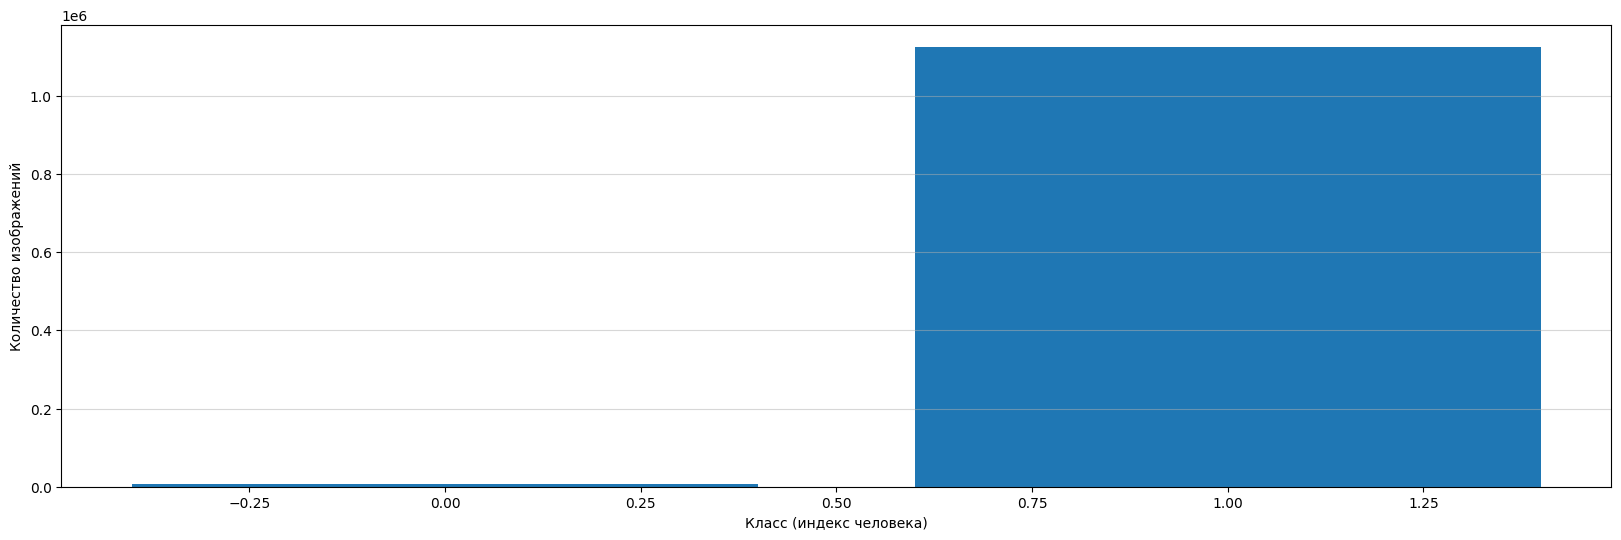

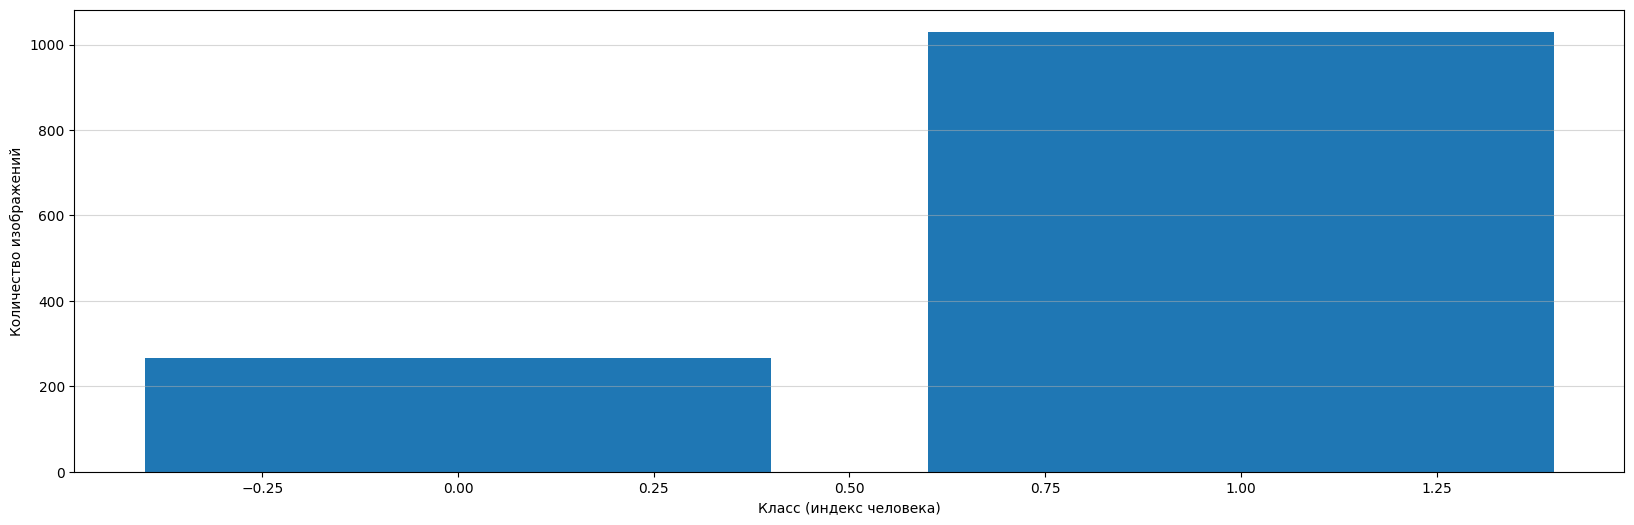

In [ ]:
show_class_distribtion(train_pairs.targets)
show_class_distribtion(test_pairs.targets)

Легко видеть, что пар фотографий разных людей гораздо больше, чем пар фотографий одного человека. Это вполне ожидаемо, но, если не предпринять мер, ведет к двум проблемам:
1. Метрика качества предсказаний должна учитывать дисбаланс классов. В частности, accuracy нам не подойдёт. А использовать будем известный из курса машинного обучения AUC-ROC.
2. Нужно "подтюнить" даталоадер тренировочных данных, чтобы в каждый батч попадало примерно одинаковое количество фотографий каждого класса. Иначе победить деградацию модели к "всегда 1" будет очень сложно.

##### [1 балл] Задание 1.3. Стратифицированный даталоадер.

Для начала решим вторую проблему. Нужно сделать такой даталоадер, чтобы в каждом батче количество элементов класса "0" совпадало с количеством элементов класса "1".

Как известно, стандартный класс `DataLoader` в torch имеет много параметров. В частности, параметр `sampler` позволяет гибко управлять выдачей. Изучите [документацию](https://docs.pytorch.org/docs/stable/data.html#data-loading-order-and-sampler) и реализуйте свой семплер, который решит проблему.

В `pytorch_metric_learning` уже есть готовая реализация того, что нам нужно. Вы можете её найти и использовать. Но в таком случае __максимальный балл за это задание - 0.4__.

In [ ]:
from torch.utils.data import Sampler
import numpy as np
import math
class BalancedSampler(Sampler):
    def __init__(self, dataset, batch_size=32, num_batches=500, seed=42):
        self.dataset = dataset
        self.batch_size = batch_size
        self.num_batches = num_batches
        self.rng = np.random.default_rng(seed)

        targets = np.array(dataset.targets)

        self.class0_indices = np.where(targets == 0)[0]
        self.class1_indices = np.where(targets == 1)[0]


        self.rng.shuffle(self.class0_indices)
        self.rng.shuffle(self.class1_indices)

    def __iter__(self):
        for _ in range(self.num_batches):
            half_batch = self.batch_size // 2

            class0_samples = self.rng.choice(
                self.class0_indices,
                size=half_batch,
                replace=len(self.class0_indices) < half_batch
            )
            class1_samples = self.rng.choice(
                self.class1_indices,
                size=half_batch,
                replace=len(self.class1_indices) < half_batch
            )

            batch_indices = np.concatenate([class0_samples, class1_samples])
            self.rng.shuffle(batch_indices)

            yield from batch_indices

    def __len__(self):
        return self.num_batches * self.batch_size

In [ ]:
set_random_seed(42)
train_pairs_sampler = BalancedSampler(train_pairs, batch_size=32, num_batches=500, seed=42)

train_loader = torch.utils.data.DataLoader(
    train_pairs,
    batch_size=32,
    sampler=train_pairs_sampler
)

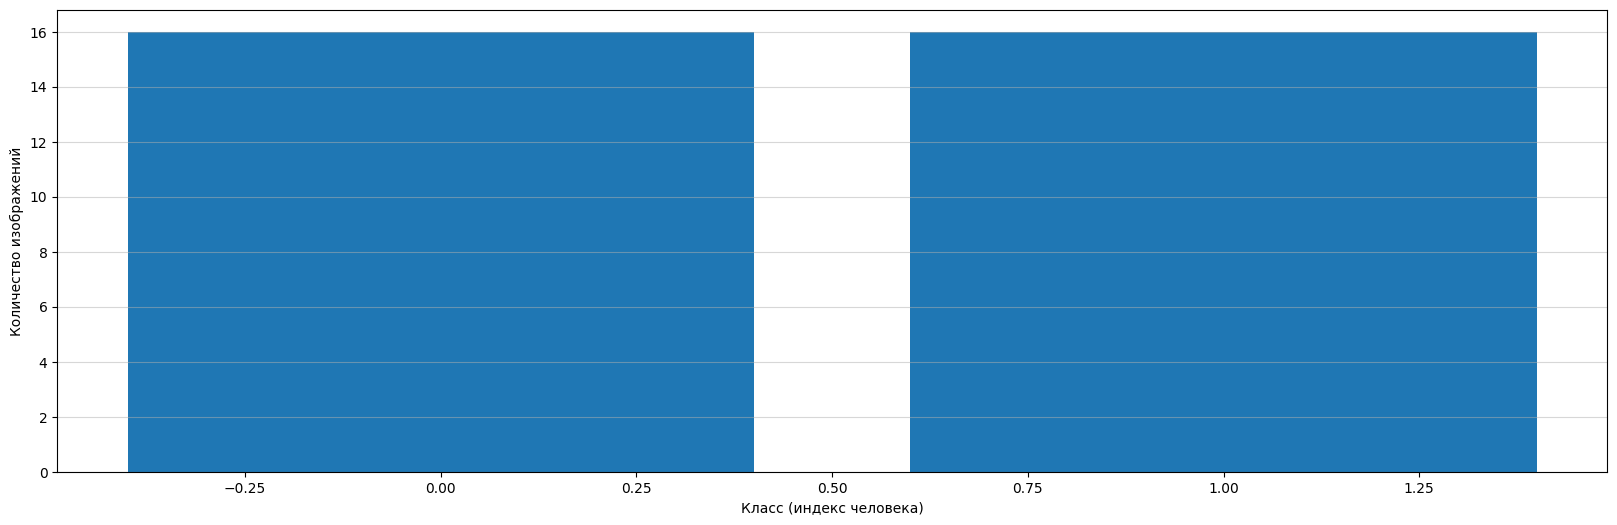

In [ ]:
set_random_seed(42)
train_pairs_loader = torch.utils.data.DataLoader(train_pairs, batch_size = 32, sampler = train_pairs_sampler)
test_pairs_loader = torch.utils.data.DataLoader(test_pairs, batch_size = 64, shuffle = False)

# Убедимся, что теперь выдача равномерная.
show_class_distribtion(next(iter(train_pairs_loader))[2])

In [ ]:
len(train_pairs_loader)

500

In [ ]:
len(test_pairs_loader)

21

### [3.5 балла] Часть 2. Классификация.

Начнём с простого: попробуем решить проблему как обычную задачу бинарной классификации. Реализуйте и обучите обычную свёрточную сеть, которая принимает два набора фотографий и предсказывает вероятность, что это фотографии разных людей.

##### [1 балл] Задание 2.1. Модель классификации.

Сначала нужно реализовать модель. В `forward` необходимо принять два батча фотографий. `i`-e число в выводе `forward` должно быть предсказанием для пары из `i`-й фотографии `image1` и `i`-й фотографии `image2`. Подумайте, как это сделать. Возможно, стоит как-нибудь склеить `image1` и `image2`? Или склеить эмбеддинги? А может быть нужен какой-то трешхолд?

Вы вольны использовать любую архитектуру сети. Ассерт в конце ячейки поможет вам убедиться, что модель теоретически делает то, что нужно.

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class ClassificationNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.cnn = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((4, 4)) # 128 x 4 x 4
        )


        self.fc = nn.Sequential(
            nn.Linear(128 * 4 * 4 * 3, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1)
        )

    def forward(self, image1, image2):
        f1 = self.cnn(image1)
        f2 = self.cnn(image2)


        f1 = f1.flatten(1)
        f2 = f2.flatten(1)

        diff = torch.abs(f1 - f2)
        x = torch.cat([f1, f2, diff], dim=1)

        out = self.fc(x)
        out = out.squeeze(1)
        return out

assert ClassificationNet()(*next(iter(train_pairs_loader))[:2]).shape == (32,)

##### [2 балла] Задание 2.2. Обучение.

Теперь обучите свою модель и добейтесь приемлемого качества. Балл за это задание вычисляется по формуле:

$$ clamp(0, 2.5 \cdot \dfrac{AucRoc - 0.6}{0.2}, 2.5) $$

То есть, для получения полного балла за это задание необходимо добиться AUC-ROC `0.8`

__При использовани предобученных моделей, балл за это задание умножается на 0.5__ (то есть, не более 1)

In [ ]:
from tqdm import tqdm
def training_epoch(model, optimizer, criterion, train_loader, tqdm_desc):
    train_loss = 0.0
    all_targets = []
    all_outputs = []

    model.train()

    for image1, image2, labels in tqdm(train_loader, desc=tqdm_desc):
        image1, image2 = image1.to(device), image2.to(device)
        labels = labels.float().to(device)

        optimizer.zero_grad()
        logits = model(image1, image2)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * labels.size(0)
        probs = torch.sigmoid(logits).detach().cpu().numpy()
        all_outputs.extend(probs)
        all_targets.extend(labels.cpu().numpy())


    train_loss /= len(train_loader.dataset)
    train_auc = roc_auc_score(all_targets, all_outputs)
    return train_loss, train_auc


@torch.no_grad()
def evaluating_epoch(model, criterion, val_loader, tqdm_desc):
    val_loss = 0.0
    all_targets = []
    all_outputs = []

    model.eval()
    for image1, image2, labels in tqdm(val_loader, desc=tqdm_desc):
        image1, image2 = image1.to(device), image2.to(device)
        labels = labels.float().to(device)

        logits = model(image1, image2)
        loss = criterion(logits, labels)

        val_loss += loss.item() * labels.size(0)
        probs = torch.sigmoid(logits).cpu().numpy()
        all_outputs.extend(probs)
        all_targets.extend(labels.cpu().numpy())

    val_loss /= len(val_loader.dataset)
    val_auc = roc_auc_score(all_targets, all_outputs)
    return val_loss, val_auc


def train(model, optimizer, criterion, train_loader, val_loader, num_epochs, scheduler=None):
    train_losses, train_aucs = [], []
    val_losses, val_aucs = [], []

    best_auc = 0.0

    for epoch in range(1, num_epochs + 1):
        train_loss, train_auc = training_epoch(
            model, optimizer, criterion, train_loader,
            tqdm_desc=f'Training {epoch}/{num_epochs}'
        )
        val_loss, val_auc = evaluating_epoch(
            model, criterion, val_loader,
            tqdm_desc=f'Evaluating {epoch}/{num_epochs}'
        )

        train_losses.append(train_loss)
        train_aucs.append(train_auc)
        val_losses.append(val_loss)
        val_aucs.append(val_auc)

        print(f"\nEpoch {epoch:02d}/{num_epochs}: "
              f"Train Loss = {train_loss:.4f}, Test Loss = {val_loss:.4f}, "
              f"Train AUC = {train_auc:.4f}, Test AUC = {val_auc:.4f}")

        if val_auc > best_auc:
            best_auc = val_auc
            torch.save(model.state_dict(), "best_model_auc.pth")

    print(f"\n Лучший AUC-ROC: {best_auc:.4f}")

    return train_losses, val_losses, train_aucs, val_aucs

In [ ]:
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.metrics import roc_auc_score, accuracy_score
import time

set_random_seed(42)
NUM_EPOCH = 10


model = ClassificationNet().to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)

train(model, optimizer, criterion, train_pairs_loader, test_pairs_loader, NUM_EPOCH)


Evaluating 1/10: 100%|██████████| 21/21 [00:11<00:00,  1.77it/s]



Epoch 01/10: Train Loss = 0.0082, Test Loss = 0.3538, Train AUC = 0.7551, Test AUC = 0.8810


Evaluating 2/10: 100%|██████████| 21/21 [00:10<00:00,  1.96it/s]



Epoch 02/10: Train Loss = 0.0074, Test Loss = 0.3664, Train AUC = 0.8104, Test AUC = 0.8931


Evaluating 3/10: 100%|██████████| 21/21 [00:11<00:00,  1.90it/s]


...

Evaluating 9/10: 100%|██████████| 21/21 [00:10<00:00,  2.04it/s]



Epoch 09/10: Train Loss = 0.0055, Test Loss = 0.2902, Train AUC = 0.9006, Test AUC = 0.9441


Evaluating 10/10: 100%|██████████| 21/21 [00:10<00:00,  1.94it/s]


Epoch 10/10: Train Loss = 0.0056, Test Loss = 0.2774, Train AUC = 0.8997, Test AUC = 0.9406

 Лучший AUC-ROC: 0.9441


([0.008189759744125676,
  0.007413267439869319,
  0.0069772199316986885,
  0.006719495062868108,
  0.006469101341109833,
  0.0062518287416031965,
  0.0060727896494143264,
  0.0058348144947117505,
  0.005549120524753122,
  0.005579506000623985],
 [0.3538062097849669,
  0.36644300045790495,
  0.3861215327992851,
  0.3345317038488977,
  0.32424014659575473,
  0.360412413691297,
  0.37352163151458456,
  0.2829036694249989,
  0.290199926605931,
  0.2774237677638913],
 [np.float64(0.7551150859375),
  np.float64(0.8103601718750001),
  np.float64(0.8357249375),
  np.float64(0.849535328125),
  np.float64(0.8620820312500002),
  np.float64(0.8718820859375002),
  np.float64(0.8794192890624999),
  np.float64(0.8891748828125001),
  np.float64(0.9006057421875001),
  np.float64(0.8996847109375001)],
 [np.float64(0.881020512446164),
  np.float64(0.8930688371413973),
  np.float64(0.9017629024016353),
  np.float64(0.9234907657493248),
  np.float64(0.9234871158478722),
  np.float64(0.9253887145047084),
  

In [ ]:
model.load_state_dict(torch.load("best_model_auc.pth"))

<All keys matched successfully>

In [ ]:
def get_score(auc_roc):
    return max(0, min(2.5 * (auc_roc - 0.6) / 0.2, 2.5))

def get_auc_roc(your_model):
    preds = []
    targets = []
    your_model.eval()
    for images1, images2, labels in tqdm(test_pairs_loader):
        with torch.no_grad():
            output = your_model(images1.to(device), images2.to(device))
        preds.extend(output.detach().cpu().tolist())
        targets.extend(labels.detach().cpu().tolist())
    preds = numpy.array(preds)
    targets = numpy.array(targets)
    return sklearn.metrics.roc_auc_score(targets, preds)

get_score(get_auc_roc(model))

100%|██████████| 21/21 [00:11<00:00,  1.91it/s]


2.5

##### [0.5 балла] Задание 2.3. Анализ и отчет.

Опишите свои эксперименты. Проанализируйте результаты. Почему результаты получились не очень хорошими? Может быть, решать задачу через бинарную классификацию - не лучшая идея? Приведите не менее 3 аргументов, почему это так.


Эксперимент проводился на простой сверточной сети. Добиться хорошего результата было задачей не из легких.Я увеличила число эпох до 10, также применила аугментацию, качсетво стало расти, когда я углублила архитектуру самой модели и использовала модуль разности для эмбеддингов, чтобы большее значение означало непохожесть людей.

Результаты показали, что модель неплохо различает пары изображений, но бинарная классификация в данном случае не совсем хороша.

1) Можно заметить признаки переобучения, лосс на трейне очень маленьй всегда, значит модель на таком количтсве однообразных пар переобучилась. То есть модель ограничена в своей способности к обобщению.

2) Такая классификация строится на распозновании различий между парами и из-за этого не определяет уникальность человека. То есть эта модель лишь говорит это один и тот же человек или нет, без упоминания степени различия между ними.

3) Квадратичный рост сложности данных, то есть с ростом количества изображений число пар растет в квадрате: модель становится огромной и долго обучается, вдобавок большой дисбаланс между классами, так как па с разными людьми намного больше, чем с одинаковыми.


### [5 баллов] Часть 3. Распознавание лиц.

Теперь попробуем использовать более хитрые методы, которые лучше подходят для решаемой задачи. В частности, триплетную функцию потерь. Далее наша модель будет не предсказывать вероятность для двух картинок, а формировать эмбеддинги для одной картинки таким образом, чтобы эмбеддинги фотографий одного человека были близки, а разных людей - далеки.

##### [2 балла] Задание 3.1. Триплетная функция потерь.

Напомним теорию. Пусть $A$ - произвольное изображение; $P$ - изображение того же человека (позитивный пример); $N$ - изображение любого другого человека (негативный пример); $f$ - наша нейронная сеть; $\alpha$ - гиперпараметр, отвечающий за желаемый “отступ” – расстояние между латентными представлениями изображений разных людей. Тогда функционал ошибки определяется следующим образом:

$$ L(A, P, N) = max(||f(A) - f(P)|| - ||f(A) - f(N)|| + \alpha, 0) $$

В этом задании вам необходимо реализовать этот функционал. Для удобства в дальнейшем, предлагается сразу реализовать batch-версию. Таким образом, на входе должно быть 2 параметра:
- Набор эмбеддингов размера (batch_size, embedding_size)
- Набор классов (номера людей, чьи это фотографии) размера (batch_size)

Ваша функция должна найти все тройки $(A, P, N)$ и вычислить лосс для них.

В `pytorch_metric_learning` уже есть готовая реализация. Вы можете её найти и использовать. Но в таком случае __максимальный балл за это задание - 0.5__.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class TripletLoss(nn.Module):
    def __init__(self, margin=0.25):
        super().__init__()
        self.margin = margin

    def forward(self, embeddings, labels):
        device = embeddings.device
        batch_size = embeddings.size(0)

        distances = torch.cdist(embeddings, embeddings, p=2)

        loss = 0.0
        triplet_count = 0

        for i in range(batch_size):
            anchor_label = labels[i]
            positive_mask = (labels == anchor_label) & (torch.arange(batch_size, device=device) != i)
            negative_mask = (labels != anchor_label)

            pos_dist = distances[i][positive_mask]
            neg_dist = distances[i][negative_mask]

            for pd in pos_dist:
                for nd in neg_dist:
                    loss += F.relu(pd - nd + self.margin)
                    triplet_count += 1

        if triplet_count == 0:
            return torch.tensor(0.0, device=device, requires_grad=True)

        return loss / triplet_count

In [ ]:
criterion = TripletLoss(margin=0.25)

In [ ]:
# Вы можете использовать этот ассерт в качестве теста
embeddings = torch.tensor([
    [ 1., 2, 3 ],
    [ 1, 3, 4 ],
    [ 4, 5, 6 ]
])
labels = torch.tensor([ 1., 2, 1 ])
assert (criterion(embeddings, labels) - 2.6775) < 1e-4

##### [3 балла] Задание 3.2. Обучение.

Теперь обучите модель и добейтесь приемлемого качества. Балл за это задание вычисляется по формуле:

$$ clamp(0, 3 \cdot \dfrac{AucRoc - 0.8}{0.15}, 3) $$

То есть, для получения полного балла за это задание необходимо добиться AUC-ROC `0.95`

При необходимости, вы можете улучшить функцию потерь. Например, учитывать не все тройки, а только "сложные", как это умеет делать реализация в `pytorch_metric_learning`. Также подумайте над даталоадером. Возможно, имеет смысл брать в батч одинаковое количество фотографий каждого человека по аналгии с заданием 1.3? Тем не менее имейте в виду, что для получения полного балла за задание, вы должны реализовать все модификации самостоятельно, а не использовать готовые.

__При использовани предобученных моделей, балл за это задание умножается на 0.5__ (то есть, не более 1.5) \
__При использовани pytorch_metric_learning, балл за это задание уменьшается на 0.5 за каждое использование__

In [ ]:
# Сделаем сначала новый семплер
import numpy as np
from torch.utils.data import Sampler

class NewSampler(Sampler):
    def __init__(self, dataset, P=16, I=4, num_batches=50, seed=42):
        self.P = P # кол-во разных людей
        self.I = I # кол-во изображений у каждого
        self.batch_size = P * I
        self.num_batches = num_batches
        self.rng = np.random.default_rng(seed)
        self.seed = seed

        targets = np.array(dataset.targets)
        self.class_to_indices = {}

        for c in np.unique(targets):
            self.class_to_indices[int(c)] = np.where(targets == c)[0]

        self.classes = list(self.class_to_indices.keys())

    def __iter__(self):
        for _ in range(self.num_batches):
            replace_classes = len(self.classes) < self.P
            chosen_classes = self.rng.choice(self.classes, size=self.P, replace=replace_classes)
            batch = []
            for c in chosen_classes:
                indices = self.class_to_indices[c]
                replace = len(indices) < self.I
                selected = self.rng.choice(indices, size=self.I, replace=replace)
                batch.extend(selected.tolist())

            self.rng.shuffle(batch)
            yield from batch

    def __len__(self):
        return self.num_batches * self.batch_size

In [ ]:
set_random_seed(42)
P, I = 16, 4
train_sampler = NewSampler(train_ds, P=P, I=I, num_batches=50)
train_loader = DataLoader(train_ds, batch_size=P*I, sampler=train_sampler, num_workers=2)

test_loader = DataLoader(test_ds, batch_size=4, shuffle=False, num_workers=2)

In [ ]:
len(train_loader)

50

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class FaceEmbeddingNet(nn.Module):
    def __init__(self, embedding_dim=256):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((4, 4))  # 256 x 4 x 4
        )

        self.fc = nn.Sequential(
            nn.Linear(256 * 4 * 4, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, embedding_dim)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        x = F.normalize(x, p=2, dim=1)
        return x

In [ ]:
import torch
import torch.nn.functional as F
from tqdm import tqdm
from sklearn.metrics import roc_auc_score

def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    total_loss = 0

    for images, labels in tqdm(dataloader, desc="Training"):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        embeddings = model(images)
        loss = criterion(embeddings, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    return total_loss / len(dataloader)


def evaluate(model, dataloader, device):
    model.eval()
    all_embeds, all_labels = [], []

    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc="Evaluating"):
            images = images.to(device)
            embeddings = model(images)
            all_embeds.append(embeddings.cpu())
            all_labels.append(labels)

    all_embeds = torch.cat(all_embeds)
    all_labels = torch.cat(all_labels)

    sim = F.cosine_similarity(all_embeds.unsqueeze(1), all_embeds.unsqueeze(0), dim=-1).cpu().numpy() # чем ближе к 1, тем более похожи эмбеддинги
    labels_matrix = (all_labels.unsqueeze(1) == all_labels.unsqueeze(0)).cpu().numpy()

    auc = roc_auc_score(labels_matrix.flatten(), sim.flatten())
    return auc

In [ ]:
set_random_seed(42)

model = FaceEmbeddingNet(embedding_dim=256).to(device)
criterion = TripletLoss(margin=0.25)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

NUM_EPOCHS = 7
best_auc = 0
for epoch in range(NUM_EPOCHS):
    train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
    test_auc = evaluate(model, test_loader, device)

    print(f"Epoch {epoch+1}: Train Loss = {train_loss:.4f}, Test AUC = {test_auc:.4f}")

    if test_auc > best_auc:
        best_auc = test_auc
        torch.save(model.state_dict(), 'best_model.pth')

    scheduler.step()

print(f"Best AUC: {best_auc:.4f}")

Evaluating: 100%|██████████| 9/9 [00:06<00:00,  1.32it/s]


Epoch 1: Train Loss = 0.1709, Test AUC = 0.8799


Evaluating: 100%|██████████| 9/9 [00:00<00:00, 34.78it/s]


Epoch 2: Train Loss = 0.1256, Test AUC = 0.9235


Evaluating: 100%|██████████| 9/9 [00:00<00:00, 38.42it/s]


...

Epoch 5: Train Loss = 0.0755, Test AUC = 0.9443


Evaluating: 100%|██████████| 9/9 [00:00<00:00, 37.48it/s]


Epoch 6: Train Loss = 0.0691, Test AUC = 0.9380


Evaluating: 100%|██████████| 9/9 [00:00<00:00, 35.53it/s]

Epoch 7: Train Loss = 0.0601, Test AUC = 0.9551
Best AUC: 0.9551


In [ ]:
def get_score(auc_roc):
    return max(0, min(3 * (auc_roc - 0.8) / 0.15, 3))

def get_auc_roc(your_model):
    preds = []
    targets = []
    your_model.eval()
    for images1, images2, labels in tqdm(test_pairs_loader):
        with torch.no_grad():
            emb1 = your_model(images1.to(device))
            emb2 = your_model(images2.to(device))
            # Вы можете изменить функцию расстояния между эмбеддингами, если считаете нужным
            dist = ((emb1 - emb2) ** 2).sum(dim = 1)
        preds.extend(dist.detach().cpu().tolist())
        targets.extend(labels.detach().cpu().tolist())
    preds = numpy.array(preds)
    targets = numpy.array(targets)
    return sklearn.metrics.roc_auc_score(targets, preds)

get_score(get_auc_roc(model))

100%|██████████| 21/21 [00:11<00:00,  1.83it/s]


3

Видно, что модель обучается быстро, и AUC хороший. Чтобы достичь этого качества, я написала новый семплер - NewSampler, который формирует батчи с P классами и I изображениями каждого человека, чтобы он работал совместно с трпилетной функцией потерь. так как Triplet Loss требует, чтобы в батче было достаточно положительных примеров (одинаковые люди) и отрицательных примеров (разные люди) для каждой якорной картинки. P — количество разных людей (классов) в батче, I — количество изображений каждого человека. Для корректного вычисления Триплет лоссанужно гараниторованно выбирать хотя бы один положительный и несколько отрицательных примеров, с чем помогает семплер.

Обучение проводилось с использованием 50 батчей на эпоху, всего 7 эпох взяла, пяти было недостаточно.